# Return Prediction using Logistic Regression

This notebook builds a Logistic Regression model to predict whether an order is likely to be returned based on customer, product, and order-related features.

In [2]:
# =====================================================
# Import Required Libraries
# =====================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("cleaned_ecommerce_dataset.csv")

df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivered_date,region,returned,request_date,return_reason,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,2023-12-27,West,No,NaN,No Return,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,2025-04-09,South,No,NaN,No Return,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,2024-10-12,North,No,NaN,No Return,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,Upi,2024-09-14,2024-09-20,South,No,NaN,No Return,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,Cod,2024-12-21,2024-12-27,East,No,NaN,No Return,13.88,2.74,1.15,39,Male


In [4]:
print(df.shape)

df.info()

(34500, 19)
<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         34500 non-null  str    
 1   customer_id      34500 non-null  str    
 2   product_id       34500 non-null  str    
 3   category         34500 non-null  str    
 4   price            34500 non-null  float64
 5   discount         34500 non-null  float64
 6   quantity         34500 non-null  int64  
 7   payment_method   34500 non-null  str    
 8   order_date       34500 non-null  str    
 9   delivered_date   34500 non-null  str    
 10  region           34500 non-null  str    
 11  returned         34500 non-null  str    
 12  request_date     1903 non-null   str    
 13  return_reason    34500 non-null  str    
 14  total_amount     34500 non-null  float64
 15  shipping_cost    34500 non-null  float64
 16  profit_margin    34500 non-null  float64
 17  customer_ag

# Feature Selection

Feature selection is the process of choosing the most relevant variables for predicting product returns.

In this project:
- The target variable is **returned**.
- Identifier columns such as Order ID and Customer ID are excluded because they do not contribute to prediction.
- Return request information is excluded to avoid data leakage, since it is only available after a return has been initiated.

In [5]:
# =====================================================
# Feature Selection
# =====================================================

features = [
    'category',
    'price',
    'discount',
    'quantity',
    'payment_method',
    'region',
    'total_amount',
    'shipping_cost',
    'profit_margin',
    'customer_age',
    'customer_gender'
]

X = df[features]

y = df['returned']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (34500, 11)
Target Shape : (34500,)


## Encoding Categorical Variables

Categorical variables are converted into numerical format using Label Encoding to make them suitable for machine learning algorithms.

In [6]:
# =====================================================
# Label Encoding
# =====================================================

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = [
    'category',
    'payment_method',
    'region',
    'customer_gender'
]

for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(X[col])

    label_encoders[col] = le

# Encode Target Variable

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print("Encoding Completed Successfully!")

Encoding Completed Successfully!


In [7]:
X.head()

,category,price,discount,quantity,payment_method,region,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,4,164.08,0.15,1,1,4,139.47,7.88,31.17,60,0
1,3,24.73,0.00,1,1,3,24.73,4.60,-2.62,37,1
2,1,175.58,0.05,1,1,2,166.80,6.58,13.44,34,1
3,1,63.67,0.00,1,4,3,63.67,5.50,2.14,21,0
4,4,16.33,0.15,1,0,1,13.88,2.74,1.15,39,1


In [8]:
# =====================================================
# Train Test Split
# =====================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (27600, 11)
Testing Set : (6900, 11)


## Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. In this project, it is used to predict whether an order is likely to be returned based on product, customer, and order-related features.

In [9]:
# =====================================================
# Train Logistic Regression Model
# =====================================================

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


## Model Prediction

The trained model is used to predict whether an order will be returned using the testing dataset.

In [10]:
# =====================================================
# Predict on Test Data
# =====================================================

y_pred = model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [11]:
# =====================================================
# Accuracy Score
# =====================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.2%}")

Accuracy : 54.67%


In [12]:
# =====================================================
# Classification Report
# =====================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.55      0.70      6519
           1       0.07      0.55      0.12       381

    accuracy                           0.55      6900
   macro avg       0.51      0.55      0.41      6900
weighted avg       0.90      0.55      0.66      6900



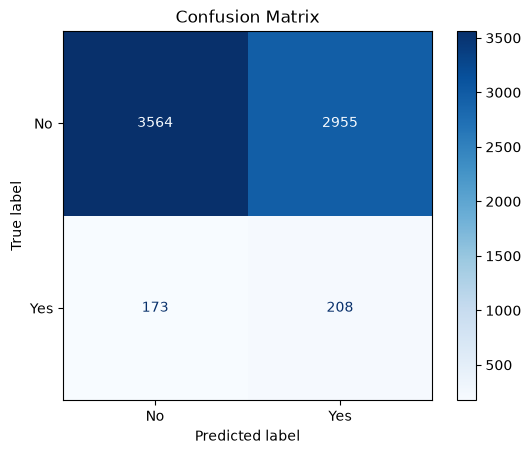

In [13]:
# =====================================================
# Confusion Matrix
# =====================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [14]:
# =====================================================
# Predict Class Labels and Probabilities
# =====================================================

y_pred = model.predict(X_test)

# Probability of the positive class (Returned = 1)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions completed successfully!")

Predictions completed successfully!


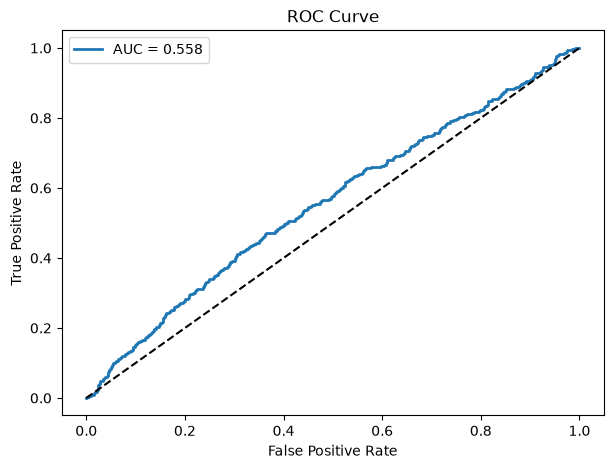

AUC Score : 0.558


In [15]:
# =====================================================
# ROC Curve
# =====================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print(f"AUC Score : {auc_score:.3f}")

In [16]:
print(df["returned"].value_counts())

returned
No     32597
Yes     1903
Name: count, dtype: int64


In [17]:
print(pd.Series(y).value_counts())

0    32597
1     1903
Name: count, dtype: int64


In [18]:
print(target_encoder.classes_)

['No' 'Yes']


# Improving Model Performance using SMOTE

The initial Logistic Regression model achieved high accuracy but failed to correctly identify returned orders due to severe class imbalance.

To address this issue, SMOTE (Synthetic Minority Oversampling Technique) is applied to the training dataset. SMOTE generates synthetic samples for the minority class, helping the model learn return patterns more effectively.

In [19]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [20]:
# =====================================================
# Import SMOTE
# =====================================================

from imblearn.over_sampling import SMOTE

In [21]:
# =====================================================
# Apply SMOTE to Balance the Training Data
# =====================================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original Training Set Shape:")
print(X_train.shape)
print(pd.Series(y_train).value_counts())

print("\nBalanced Training Set Shape:")
print(X_train_smote.shape)
print(pd.Series(y_train_smote).value_counts())

Original Training Set Shape:
(27600, 11)
0    26078
1     1522
Name: count, dtype: int64

Balanced Training Set Shape:
(52156, 11)
1    26078
0    26078
Name: count, dtype: int64


In [22]:
# =====================================================
# Train Logistic Regression after SMOTE
# =====================================================

model_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model_smote.fit(X_train_smote, y_train_smote)

print("Logistic Regression trained on balanced data.")

Logistic Regression trained on balanced data.


C:\Users\JANANI MAHAVISHNU\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
# =====================================================
# Predict using SMOTE Model
# =====================================================

y_pred_smote = model_smote.predict(X_test)

y_prob_smote = model_smote.predict_proba(X_test)[:, 1]

print("✅ Predictions Completed Successfully!")

✅ Predictions Completed Successfully!


In [24]:
# =====================================================
# Accuracy Score
# =====================================================

from sklearn.metrics import accuracy_score

accuracy_smote = accuracy_score(y_test, y_pred_smote)

print(f"Accuracy : {accuracy_smote:.2%}")

Accuracy : 60.72%


In [25]:
# =====================================================
# Classification Report
# =====================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_smote, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.62      0.75      6519
           1       0.06      0.43      0.11       381

    accuracy                           0.61      6900
   macro avg       0.51      0.52      0.43      6900
weighted avg       0.90      0.61      0.71      6900



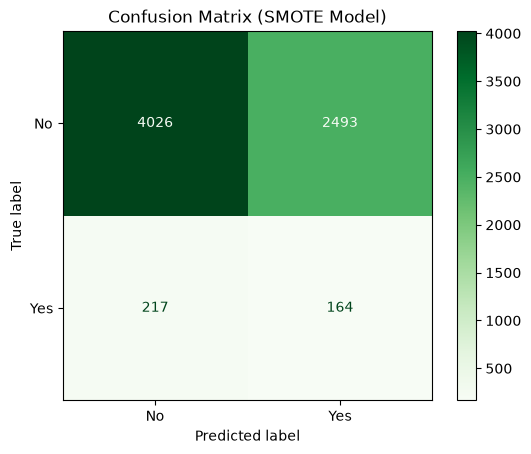

In [26]:
# =====================================================
# Confusion Matrix
# =====================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_smote)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix (SMOTE Model)")

plt.show()

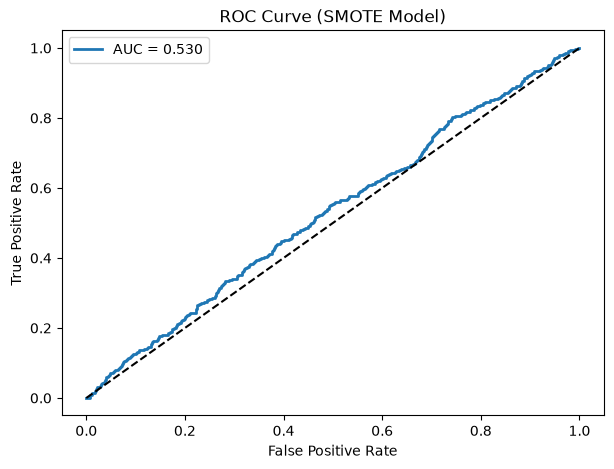

AUC Score : 0.530


In [27]:
# =====================================================
# ROC Curve and AUC Score
# =====================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_smote)

auc_score = roc_auc_score(y_test, y_prob_smote)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SMOTE Model)")
plt.legend()

plt.show()

print(f"AUC Score : {auc_score:.3f}")

# Feature Scaling

Feature scaling standardizes numerical variables so that they have similar ranges. Logistic Regression performs better when input features are scaled, leading to faster convergence and improved model performance.

In [28]:
# =====================================================
# Feature Scaling
# =====================================================

from sklearn.preprocessing import StandardScaler

# Numerical columns
numeric_features = [
    'price',
    'discount',
    'quantity',
    'total_amount',
    'shipping_cost',
    'profit_margin',
    'customer_age'
]

# Create a scaler
scaler = StandardScaler()

# Make copies of the train and test data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale only the numerical columns
X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

print("✅ Feature Scaling Completed Successfully!")

✅ Feature Scaling Completed Successfully!


# Apply SMOTE on Scaled Training Data

SMOTE is applied only to the scaled training dataset to balance the minority class (returned orders). This helps the Logistic Regression model learn from both classes without introducing information from the test set.

In [29]:
# =====================================================
# Apply SMOTE on Scaled Training Data
# =====================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original Training Set Shape :", X_train_scaled.shape)
print(pd.Series(y_train).value_counts())

print("\nBalanced Training Set Shape :", X_train_smote.shape)
print(pd.Series(y_train_smote).value_counts())

Original Training Set Shape : (27600, 11)
0    26078
1     1522
Name: count, dtype: int64

Balanced Training Set Shape : (52156, 11)
1    26078
0    26078
Name: count, dtype: int64


# Train Logistic Regression on Balanced Data

The Logistic Regression model is trained using the scaled and balanced training dataset to improve its ability to identify returned orders.

In [30]:
# =====================================================
# Train Logistic Regression
# =====================================================

from sklearn.linear_model import LogisticRegression

model_scaled = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model_scaled.fit(X_train_smote, y_train_smote)

print("✅ Logistic Regression trained successfully!")

✅ Logistic Regression trained successfully!


In [31]:
# =====================================================
# Predictions
# =====================================================

y_pred_scaled = model_scaled.predict(X_test_scaled)

y_prob_scaled = model_scaled.predict_proba(X_test_scaled)[:, 1]

print("✅ Predictions completed successfully!")

✅ Predictions completed successfully!


In [32]:
# =====================================================
# Accuracy
# =====================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_scaled)

print(f"Accuracy : {accuracy:.2%}")

Accuracy : 56.81%


In [33]:
# =====================================================
# Classification Report
# =====================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_scaled, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.57      0.71      6519
           1       0.06      0.49      0.11       381

    accuracy                           0.57      6900
   macro avg       0.51      0.53      0.41      6900
weighted avg       0.90      0.57      0.68      6900



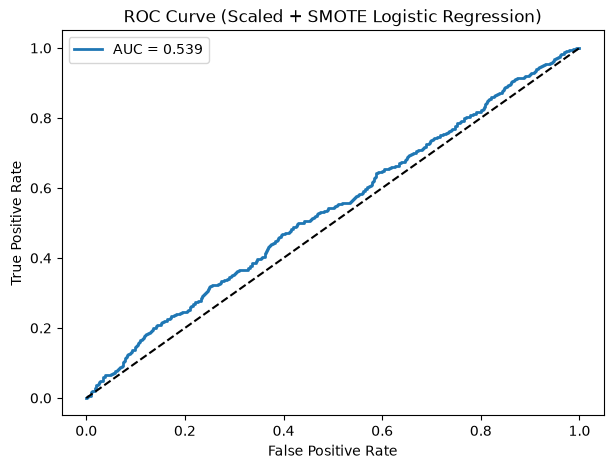

AUC Score : 0.539


In [34]:
# =====================================================
# ROC Curve & AUC
# =====================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_scaled)

auc_score = roc_auc_score(y_test, y_prob_scaled)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", linewidth=2)
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Scaled + SMOTE Logistic Regression)")
plt.legend()

plt.show()

print(f"AUC Score : {auc_score:.3f}")

In [36]:
# =====================================================
# Generate High Risk Products CSV
# =====================================================

X_all = X.copy()

# Scale numeric columns
X_all[numeric_features] = scaler.transform(X_all[numeric_features])

# Predict return probabilities
risk_probability = model_scaled.predict_proba(X_all)[:, 1]

# Create output dataframe
high_risk = df.copy()

high_risk["Return_Probability"] = risk_probability

# Create Risk Level
high_risk["Risk_Level"] = pd.cut(
    high_risk["Return_Probability"],
    bins=[0,0.30,0.60,1],
    labels=["Low","Medium","High"]
)

# Highest risk first
high_risk = high_risk.sort_values(
    by="Return_Probability",
    ascending=False
)

# Save CSV
high_risk.to_csv("High_Risk_Products.csv",index=False)

print("High_Risk_Products.csv generated successfully!")

high_risk.head()

High_Risk_Products.csv generated successfully!


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivered_date,...,returned,request_date,return_reason,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,Return_Probability,Risk_Level
27786,O127786,C16792,P248424,Electronics,225.65,0.05,1,Cod,2024-07-19,2024-07-22,...,No,NaN,No Return,214.37,9.88,15.84,42,Female,0.774007,High
21839,O121839,C10238,P232115,Electronics,286.11,0.00,1,Cod,2025-05-22,2025-05-28,...,No,NaN,No Return,286.11,9.68,24.65,33,Female,0.772152,High
1334,O101334,C15511,P216312,Electronics,341.85,0.15,1,Credit Card,2025-06-13,2025-06-17,...,No,NaN,No Return,290.57,11.51,23.36,61,Female,0.770617,High
9535,O109535,C13598,P232961,Electronics,382.59,0.00,1,Cod,2024-12-11,2024-12-19,...,No,NaN,No Return,382.59,10.53,35.38,22,Female,0.769805,High
27571,O127571,C11647,P244830,Electronics,405.06,0.00,1,Credit Card,2025-08-12,2025-08-17,...,No,NaN,No Return,405.06,11.32,37.29,43,Female,0.768860,High


In [37]:
high_risk.to_csv("High_Risk_Products.csv", index=False)